In [6]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# =========================
# 1. 경로 설정
# =========================
ROOT = Path.cwd()

# notebooks 폴더에서 실행하면 프로젝트 루트로 이동
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

candidate_paths = [
    ROOT / "outputs" / "tables" / "modeling_result_dataset.csv",
    ROOT / "data" / "processed" / "modeling_dataset.csv",
]

DATA_PATH = None
for path in candidate_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError("modeling_result_dataset.csv 또는 modeling_dataset.csv를 찾을 수 없습니다.")

OUT_TABLE_DIR = ROOT / "outputs" / "presentation_tables"
OUT_FIG_DIR = ROOT / "outputs" / "figures" / "model"

OUT_TABLE_DIR.mkdir(parents=True, exist_ok=True)
OUT_FIG_DIR.mkdir(parents=True, exist_ok=True)

print("사용 데이터:", DATA_PATH)
print("표 저장 폴더:", OUT_TABLE_DIR)
print("이미지 저장 폴더:", OUT_FIG_DIR)

# =========================
# 2. 데이터 불러오기
# =========================
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

# contract_month 처리
df["contract_month"] = pd.to_datetime(df["contract_month"], errors="coerce")

latest_month = df["contract_month"].max()
latest = df[df["contract_month"] == latest_month].copy()

print("최신 월:", latest_month.strftime("%Y-%m"))
print("최신 월 데이터 크기:", latest.shape)
print("컬럼 목록:")
print(df.columns.tolist())

사용 데이터: /Users/min/RealEstate-Risk-Radar/outputs/tables/modeling_result_dataset.csv
표 저장 폴더: /Users/min/RealEstate-Risk-Radar/outputs/presentation_tables
이미지 저장 폴더: /Users/min/RealEstate-Risk-Radar/outputs/figures/model
최신 월: 2026-04
최신 월 데이터 크기: (25, 55)
컬럼 목록:
['sggCd', 'gu', 'contract_month', 'avg_sale_price', 'med_sale_price', 'avg_sale_price_per_m2', 'med_sale_price_per_m2', 'sale_count', 'avg_jeonse_deposit', 'med_jeonse_deposit', 'avg_jeonse_deposit_per_m2', 'med_jeonse_deposit_per_m2', 'jeonse_count', 'total_rent_count', 'monthly_count', 'monthly_ratio', 'jeonse_rate', 'gap_rate', 'sale_growth_1m', 'jeonse_growth_1m', 'growth_gap_1m', 'sale_volume_growth_1m', 'rent_volume_growth_1m', 'gap_score', 'sale_growth_score', 'growth_gap_score', 'monthly_ratio_score', 'jeonse_growth_score', 'sale_volume_change_score', 'rent_volume_change_score', 'user_risk_score', 'investor_risk_score', 'total_risk_score', 'user_risk_grade', 'investor_risk_grade', 'risk_grade', 'risk_target', 'warning_f

In [7]:
# =========================
# 3. 발표용 컬럼 선택
# =========================

# 실제 컬럼명 자동 탐색
def pick_col(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

gu_col = pick_col(["gu", "region", "자치구"], latest.columns)

resident_col = pick_col(
    ["resident_risk_index", "resident_risk_score", "user_risk_score"],
    latest.columns
)

investor_col = pick_col(
    ["investor_risk_index", "investor_risk_score"],
    latest.columns
)

stagnation_col = pick_col(
    ["stagnation_score", "stagnation_risk_score"],
    latest.columns
)

total_col = pick_col(
    ["total_risk_score", "risk_score"],
    latest.columns
)

grade_col = pick_col(
    ["risk_grade", "grade", "위험등급"],
    latest.columns
)

print("자치구 컬럼:", gu_col)
print("실거주자 위험 점수 컬럼:", resident_col)
print("투자자 위험 점수 컬럼:", investor_col)
print("정체도 점수 컬럼:", stagnation_col)
print("종합 위험 점수 컬럼:", total_col)
print("위험 등급 컬럼:", grade_col)

자치구 컬럼: gu
실거주자 위험 점수 컬럼: resident_risk_index
투자자 위험 점수 컬럼: investor_risk_index
정체도 점수 컬럼: stagnation_score
종합 위험 점수 컬럼: total_risk_score
위험 등급 컬럼: risk_grade


In [8]:
# =========================
# 4. 발표용 위험 점수 표 생성
# =========================

required = [gu_col, resident_col, investor_col, stagnation_col]
if any(c is None for c in required):
    raise ValueError("필수 컬럼을 찾지 못했습니다. 위의 컬럼 목록을 확인해주세요.")

presentation = latest[[gu_col, resident_col, investor_col, stagnation_col]].copy()

presentation = presentation.rename(columns={
    gu_col: "자치구",
    resident_col: "실거주자 위험 점수",
    investor_col: "투자자 위험 점수",
    stagnation_col: "정체도 점수"
})

# 종합 위험 점수는 있으면 사용, 없으면 3개 점수 평균으로 계산
if total_col is not None:
    presentation["종합 위험 점수"] = latest[total_col].values
else:
    presentation["종합 위험 점수"] = presentation[
        ["실거주자 위험 점수", "투자자 위험 점수", "정체도 점수"]
    ].mean(axis=1)

# 위험 등급 있으면 추가
if grade_col is not None:
    presentation["위험 등급"] = latest[grade_col].values

# 숫자 반올림
score_cols = ["실거주자 위험 점수", "투자자 위험 점수", "정체도 점수", "종합 위험 점수"]
for col in score_cols:
    presentation[col] = presentation[col].round(3)

# 발표용 Top 10
presentation_top10 = (
    presentation
    .sort_values("종합 위험 점수", ascending=False)
    .head(10)
    .reset_index(drop=True)
)

presentation_top10.insert(0, "순위", range(1, len(presentation_top10) + 1))

# 저장
csv_path = OUT_TABLE_DIR / "latest_presentation_risk_table.csv"
presentation_top10.to_csv(csv_path, index=False, encoding="utf-8-sig")

print("CSV 저장 완료:", csv_path)
presentation_top10

CSV 저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/presentation_tables/latest_presentation_risk_table.csv


,순위,자치구,실거주자 위험 점수,투자자 위험 점수,정체도 점수,종합 위험 점수,위험 등급
0,1,송파구,0.912,0.881,0.20,0.896,높음
1,2,강동구,0.809,0.798,0.45,0.803,높음
2,3,서초구,0.779,0.778,0.65,0.778,높음
3,4,강남구,0.786,0.747,0.20,0.767,높음
4,5,성동구,0.686,0.754,0.20,0.720,높음
5,6,양천구,0.678,0.662,0.20,0.670,높음
6,7,구로구,0.639,0.693,0.60,0.666,높음
7,8,마포구,0.674,0.648,0.35,0.661,높음
8,9,관악구,0.648,0.575,0.00,0.612,주의
9,10,금천구,0.667,0.553,0.10,0.610,주의


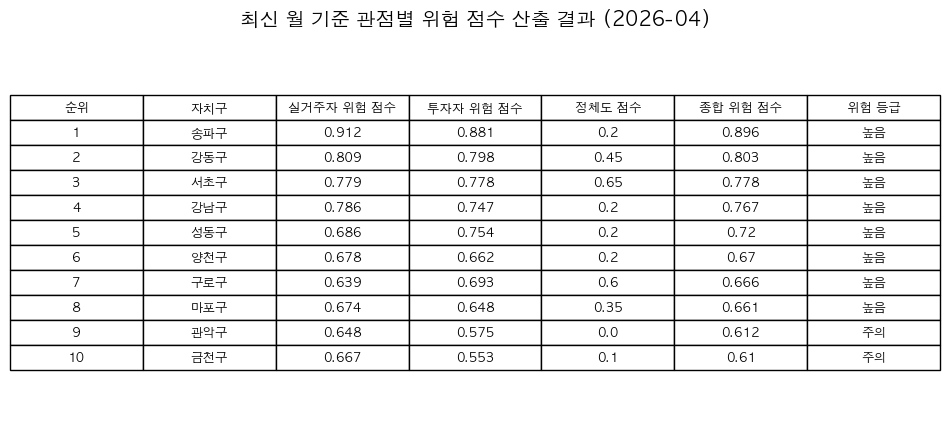

PNG 저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/figures/model/latest_presentation_risk_table.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import platform

# 한글 폰트 설정
if platform.system() == "Darwin":   # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

# =========================
# 5. PPT 삽입용 표 이미지 저장
# =========================

fig, ax = plt.subplots(figsize=(12, 4.8))
ax.axis("off")

table = ax.table(
    cellText=presentation_top10.values,
    colLabels=presentation_top10.columns,
    cellLoc="center",
    loc="center"
)

table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.5)

plt.title(
    f"최신 월 기준 관점별 위험 점수 산출 결과 ({latest_month.strftime('%Y-%m')})",
    fontsize=14,
    pad=16
)

png_path = OUT_FIG_DIR / "latest_presentation_risk_table.png"
plt.savefig(png_path, bbox_inches="tight", dpi=200)
plt.show()

print("PNG 저장 완료:", png_path)

In [10]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import platform
import warnings

warnings.filterwarnings("ignore")

# =========================
# 한글 폰트 설정
# =========================
if platform.system() == "Darwin":   # macOS
    plt.rcParams["font.family"] = "AppleGothic"
elif platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"
else:
    plt.rcParams["font.family"] = "NanumGothic"

plt.rcParams["axes.unicode_minus"] = False

# =========================
# 경로 설정
# =========================
ROOT = Path.cwd()

# notebooks 폴더에서 실행하면 프로젝트 루트로 이동
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

candidate_paths = [
    ROOT / "outputs" / "tables" / "modeling_result_dataset.csv",
    ROOT / "data" / "processed" / "modeling_dataset.csv",
]

DATA_PATH = None
for path in candidate_paths:
    if path.exists():
        DATA_PATH = path
        break

if DATA_PATH is None:
    raise FileNotFoundError("modeling_result_dataset.csv 또는 modeling_dataset.csv를 찾을 수 없습니다.")

FIG_DIR = ROOT / "outputs" / "figures" / "model"
TABLE_DIR = ROOT / "outputs" / "tables"

FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("사용 데이터:", DATA_PATH)
print("이미지 저장 폴더:", FIG_DIR)
print("표 저장 폴더:", TABLE_DIR)

사용 데이터: /Users/min/RealEstate-Risk-Radar/outputs/tables/modeling_result_dataset.csv
이미지 저장 폴더: /Users/min/RealEstate-Risk-Radar/outputs/figures/model
표 저장 폴더: /Users/min/RealEstate-Risk-Radar/outputs/tables


In [11]:
# =========================
# 데이터 불러오기
# =========================
df = pd.read_csv(DATA_PATH, encoding="utf-8-sig")

print("데이터 크기:", df.shape)
print("컬럼 목록:")
print(df.columns.tolist())

데이터 크기: (875, 55)
컬럼 목록:
['sggCd', 'gu', 'contract_month', 'avg_sale_price', 'med_sale_price', 'avg_sale_price_per_m2', 'med_sale_price_per_m2', 'sale_count', 'avg_jeonse_deposit', 'med_jeonse_deposit', 'avg_jeonse_deposit_per_m2', 'med_jeonse_deposit_per_m2', 'jeonse_count', 'total_rent_count', 'monthly_count', 'monthly_ratio', 'jeonse_rate', 'gap_rate', 'sale_growth_1m', 'jeonse_growth_1m', 'growth_gap_1m', 'sale_volume_growth_1m', 'rent_volume_growth_1m', 'gap_score', 'sale_growth_score', 'growth_gap_score', 'monthly_ratio_score', 'jeonse_growth_score', 'sale_volume_change_score', 'rent_volume_change_score', 'user_risk_score', 'investor_risk_score', 'total_risk_score', 'user_risk_grade', 'investor_risk_grade', 'risk_grade', 'risk_target', 'warning_flag', 'resident_risk_index', 'investor_risk_index', 'resident_risk_grade', 'monthly_ratio_diff', 'monthly_shift_abs', 'sale_stagnation_flag', 'jeonse_stagnation_flag', 'volume_drop_flag', 'high_gap_flag', 'rent_shift_flag', 'stagnation_sc

In [12]:
# =========================
# 컬럼 자동 탐색
# =========================
def pick_col(candidates, columns):
    for c in candidates:
        if c in columns:
            return c
    return None

gu_col = pick_col(["gu", "region", "자치구"], df.columns)
month_col = pick_col(["contract_month", "계약월"], df.columns)

resident_col = pick_col(
    ["resident_risk_index", "resident_risk_score", "user_risk_score"],
    df.columns
)

investor_col = pick_col(
    ["investor_risk_index", "investor_risk_score"],
    df.columns
)

stagnation_col = pick_col(
    ["stagnation_score", "stagnation_risk_score", "stagnation_index"],
    df.columns
)

print("자치구 컬럼:", gu_col)
print("월 컬럼:", month_col)
print("실거주자 위험 점수 컬럼:", resident_col)
print("투자자 위험 점수 컬럼:", investor_col)
print("정체도 점수 컬럼:", stagnation_col)

required_cols = [gu_col, month_col, resident_col, investor_col, stagnation_col]
if any(c is None for c in required_cols):
    raise ValueError("필수 컬럼을 찾지 못했습니다. 위 출력 결과를 확인하세요.")

자치구 컬럼: gu
월 컬럼: contract_month
실거주자 위험 점수 컬럼: resident_risk_index
투자자 위험 점수 컬럼: investor_risk_index
정체도 점수 컬럼: stagnation_score


In [13]:
# =========================
# contract_month 처리
# =========================
def convert_contract_month(series):
    s = series.copy()

    # 숫자형 202604 같은 형식 처리
    if pd.api.types.is_numeric_dtype(s):
        s = s.astype("Int64").astype(str)
    else:
        s = s.astype(str).str.strip()

    # 2026-04, 202604, 2026/04 모두 어느 정도 처리
    s = s.str.replace("/", "-", regex=False)

    parsed = pd.to_datetime(s, format="%Y%m", errors="coerce")
    parsed2 = pd.to_datetime(s, errors="coerce")

    return parsed.fillna(parsed2)

df[month_col] = convert_contract_month(df[month_col])

if df[month_col].isna().all():
    raise ValueError("contract_month 변환에 실패했습니다. 원본 값을 확인하세요.")

latest_month = df[month_col].max()
latest_df = df[df[month_col] == latest_month].copy()

print("최신 월:", latest_month.strftime("%Y-%m"))
print("최신 월 데이터 크기:", latest_df.shape)

최신 월: 2026-04
최신 월 데이터 크기: (25, 55)


In [14]:
# =========================
# 그래프 + CSV 생성 함수
# =========================
def make_top10_chart(data, score_col, title, png_filename, csv_filename):
    top10 = (
        data[[gu_col, score_col]]
        .dropna()
        .sort_values(score_col, ascending=False)
        .head(10)
        .copy()
    )

    top10[score_col] = top10[score_col].round(3)

    # CSV 저장
    csv_path = TABLE_DIR / csv_filename
    top10.to_csv(csv_path, index=False, encoding="utf-8-sig")

    # 시각화용 역순 정렬 (가로 막대 그래프 예쁘게 보이게)
    plot_df = top10.sort_values(score_col, ascending=True)

    plt.figure(figsize=(10, 6))
    plt.barh(plot_df[gu_col], plot_df[score_col])
    plt.xlabel("점수")
    plt.ylabel("자치구")
    plt.title(title)
    plt.grid(axis="x", alpha=0.3)

    for i, value in enumerate(plot_df[score_col]):
        plt.text(value + 0.005, i, f"{value:.3f}", va="center", fontsize=9)

    plt.tight_layout()

    png_path = FIG_DIR / png_filename
    plt.savefig(png_path, dpi=200, bbox_inches="tight")
    plt.show()

    print(f"CSV 저장 완료: {csv_path}")
    print(f"PNG 저장 완료: {png_path}")

    return top10

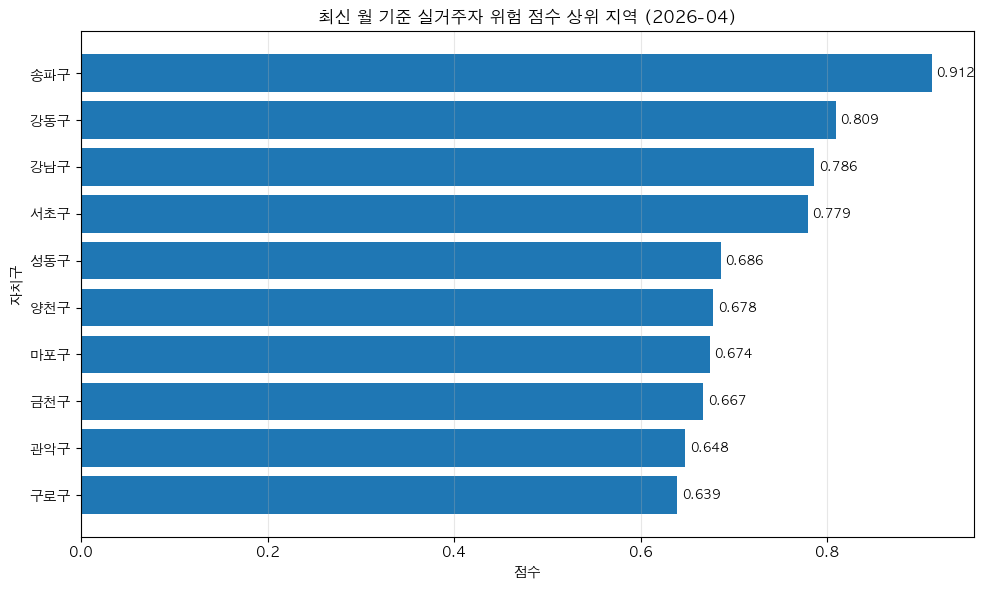

CSV 저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/tables/resident_risk_top10.csv
PNG 저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/figures/model/resident_risk_top10.png


,gu,resident_risk_index
629,송파구,0.912
69,강동구,0.809
34,강남구,0.786
524,서초구,0.779
559,성동구,0.686
664,양천구,0.678
454,마포구,0.674
279,금천구,0.667
174,관악구,0.648
244,구로구,0.639


In [15]:
# =========================
# 실거주자 위험 점수 Top 10
# =========================
resident_top10 = make_top10_chart(
    latest_df,
    resident_col,
    f"최신 월 기준 실거주자 위험 점수 상위 지역 ({latest_month.strftime('%Y-%m')})",
    "resident_risk_top10.png",
    "resident_risk_top10.csv"
)

resident_top10

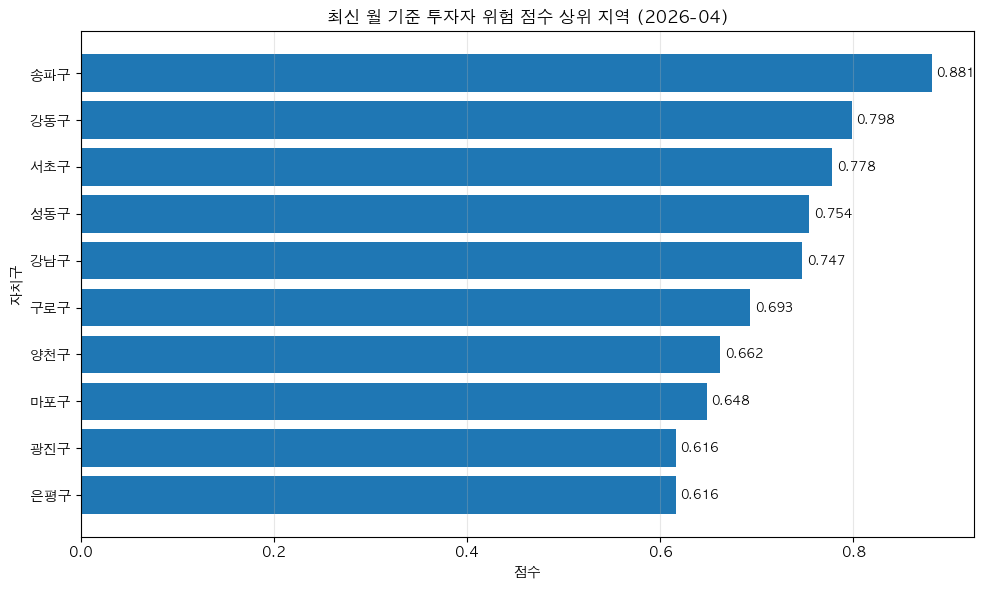

CSV 저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/tables/investor_risk_top10.csv
PNG 저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/figures/model/investor_risk_top10.png


,gu,investor_risk_index
629,송파구,0.881
69,강동구,0.798
524,서초구,0.778
559,성동구,0.754
34,강남구,0.747
244,구로구,0.693
664,양천구,0.662
454,마포구,0.648
769,은평구,0.616
209,광진구,0.616


In [16]:
# =========================
# 투자자 위험 점수 Top 10
# =========================
investor_top10 = make_top10_chart(
    latest_df,
    investor_col,
    f"최신 월 기준 투자자 위험 점수 상위 지역 ({latest_month.strftime('%Y-%m')})",
    "investor_risk_top10.png",
    "investor_risk_top10.csv"
)

investor_top10

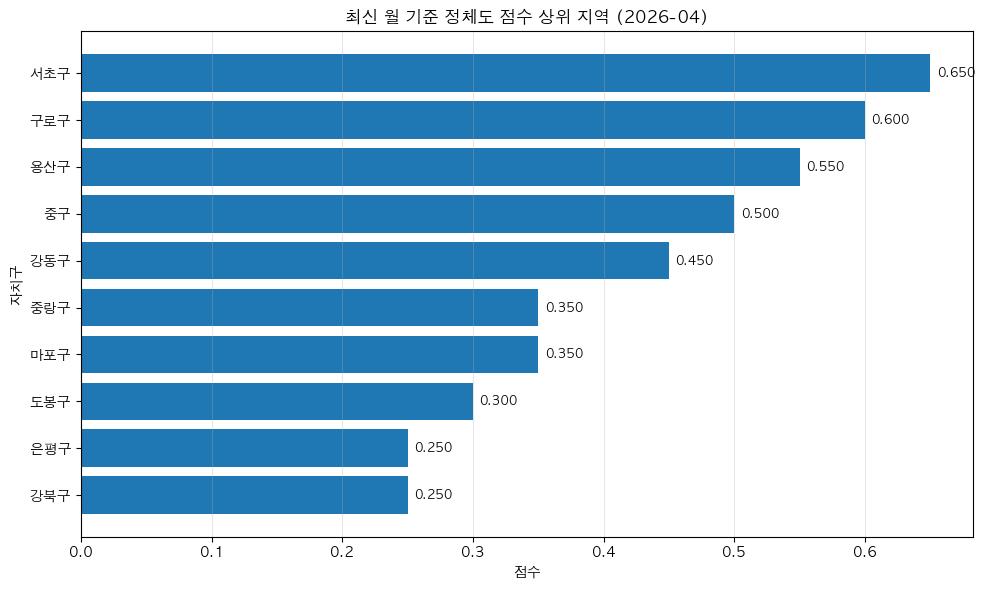

CSV 저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/tables/stagnation_score_top10.csv
PNG 저장 완료: /Users/min/RealEstate-Risk-Radar/outputs/figures/model/stagnation_score_top10.png


,gu,stagnation_score
524,서초구,0.65
244,구로구,0.60
734,용산구,0.55
839,중구,0.50
69,강동구,0.45
454,마포구,0.35
874,중랑구,0.35
349,도봉구,0.30
104,강북구,0.25
769,은평구,0.25


In [17]:
# =========================
# 정체도 점수 Top 10
# =========================
stagnation_top10 = make_top10_chart(
    latest_df,
    stagnation_col,
    f"최신 월 기준 정체도 점수 상위 지역 ({latest_month.strftime('%Y-%m')})",
    "stagnation_score_top10.png",
    "stagnation_score_top10.csv"
)

stagnation_top10